Unique values in original mask: [0. 1. 2. 4.]
Unique values in binary mask: [0 1]


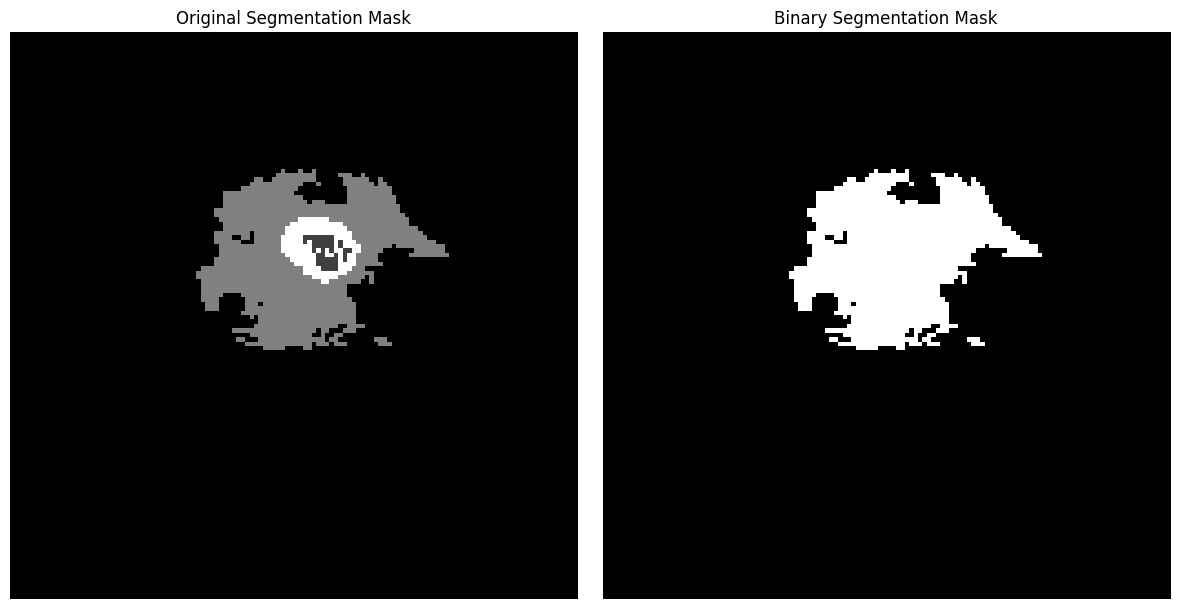

In [2]:
import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import cv2

# -----------------------------------
# STEP 1: Patient folder path
# -----------------------------------

patient_path = "../dataset/BraTs2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_001/"

# -----------------------------------
# STEP 2: File paths
# -----------------------------------

flair_path = os.path.join(patient_path, "BraTS20_Training_001_flair.nii")
t1_path = os.path.join(patient_path, "BraTS20_Training_001_t1.nii")
t1ce_path = os.path.join(patient_path, "BraTS20_Training_001_t1ce.nii")
t2_path = os.path.join(patient_path, "BraTS20_Training_001_t2.nii")
seg_path = os.path.join(patient_path, "BraTS20_Training_001_seg.nii")

# -----------------------------------
# STEP 3: Load data
# -----------------------------------

flair = nib.load(flair_path).get_fdata()
t1 = nib.load(t1_path).get_fdata()
t1ce = nib.load(t1ce_path).get_fdata()
t2 = nib.load(t2_path).get_fdata()
seg = nib.load(seg_path).get_fdata()

# -----------------------------------
# STEP 4: Select slice
# -----------------------------------

slice_num = 75

flair_slice = flair[:, :, slice_num]
t1_slice = t1[:, :, slice_num]
t1ce_slice = t1ce[:, :, slice_num]
t2_slice = t2[:, :, slice_num]
seg_slice = seg[:, :, slice_num]

# -----------------------------------
# STEP 5: Resize
# -----------------------------------

size = 128

flair_slice = cv2.resize(flair_slice, (size, size))
t1_slice = cv2.resize(t1_slice, (size, size))
t1ce_slice = cv2.resize(t1ce_slice, (size, size))
t2_slice = cv2.resize(t2_slice, (size, size))
seg_slice = cv2.resize(
    seg_slice,
    (size, size),
    interpolation=cv2.INTER_NEAREST
)

# -----------------------------------
# STEP 6: Normalize MRI slices
# -----------------------------------

def normalize(image):
    return image / np.max(image)

flair_slice = normalize(flair_slice)
t1_slice = normalize(t1_slice)
t1ce_slice = normalize(t1ce_slice)
t2_slice = normalize(t2_slice)

# -----------------------------------
# STEP 7: Convert mask to binary
# -----------------------------------

seg_binary = np.where(seg_slice > 0, 1, 0)

print("Unique values in original mask:", np.unique(seg_slice))
print("Unique values in binary mask:", np.unique(seg_binary))

# -----------------------------------
# STEP 8: Display comparison
# -----------------------------------

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(seg_slice, cmap="gray")
plt.title("Original Segmentation Mask")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(seg_binary, cmap="gray")
plt.title("Binary Segmentation Mask")
plt.axis("off")

plt.tight_layout()
plt.show()